# India Job Market Intelligence — Business Insights

This notebook presents the key business insights derived from the India Job Market Intelligence dataset.

The analysis focuses on:

- Job market demand
- Salary and compensation
- Experience requirements
- Skill requirements
- Hiring locations and companies

The insights are derived from the validated data warehouse and are intended to support data-driven understanding of the Indian technology job market.

## 1. Job Market Demand Analysis

This section analyzes which roles, skill domains, cities, and companies have the highest demand in the Indian job market.

## Q1 — Which job roles have the highest demand?

### 1.1 Most In-Demand Job Roles

This analysis identifies the job roles with the highest number of job postings in the dataset.

Understanding role demand helps identify which technology and analytics positions have the strongest presence in the current job market.

In [3]:
# importing libraries
import pandas as pd

from sqlalchemy import create_engine
from sqlalchemy import text

In [5]:
# connect to mysql
MYSQL_USER = "root"
MYSQL_PASSWORD = "27104720A"

MYSQL_HOST = "localhost"

MYSQL_PORT = 3306

MYSQL_DATABASE = "job_market_analytics"

engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
)

print("Database Connected Successfully")

Database Connected Successfully


In [12]:
top_roles = pd.read_sql("""
SELECT
    r.role_category,
    COUNT(*) AS total_jobs
FROM fact_jobs f
JOIN dim_role r
    ON f.role_key = r.role_key
GROUP BY r.role_category
ORDER BY total_jobs DESC;
""", engine)

top_roles

,role_category,total_jobs
0,Data Scientist,6455
1,Data Analyst,4729
2,Business Analyst,4505
3,Machine Learning Engineer,4004
4,Data Engineer,1922
5,Python Developer,1586


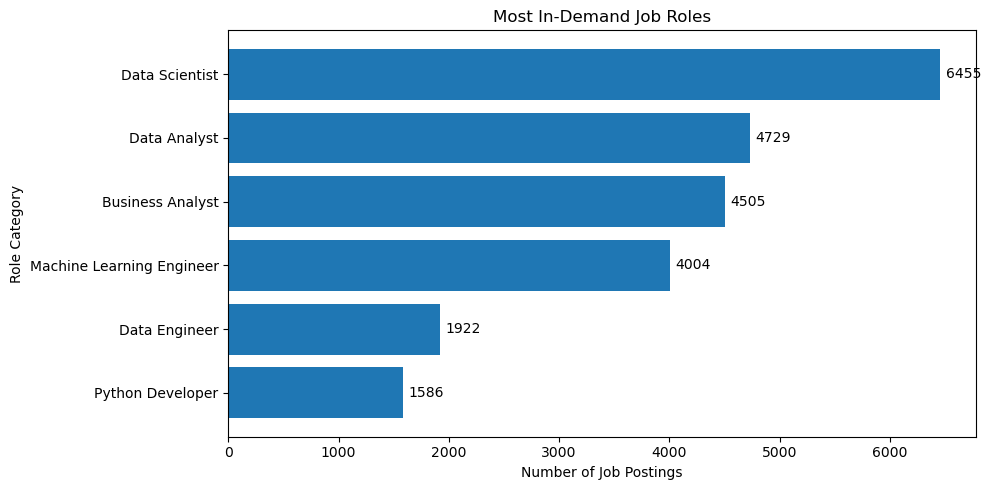

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.barh(
    top_roles["role_category"],
    top_roles["total_jobs"]
)

plt.title("Most In-Demand Job Roles")
plt.xlabel("Number of Job Postings")
plt.ylabel("Role Category")

plt.gca().invert_yaxis()

for index, value in enumerate(top_roles["total_jobs"]):
    plt.text(value + 50, index, str(value), va='center')

plt.tight_layout()
plt.show()

### Key Insight

Data Scientist roles have the highest demand in the dataset with **6,455 job postings**, followed by Data Analyst (**4,729**), Business Analyst (**4,505**), and Machine Learning Engineer (**4,004**).

Together, these four roles account for a substantial share of the analyzed technology job market, highlighting strong demand for data, analytics, and machine learning capabilities.

**Career relevance:** Data Analyst is the second-highest-demand role among the analyzed job categories, indicating strong market demand for analytical professionals.

# Q2 — Which skill domains have the highest job demand?

### 1.2 Job Demand by Skill Domain

This analysis examines the number of job postings associated with each skill domain to identify which areas of technology and analytics have the strongest demand.

In [7]:
skill_demand = pd.read_sql("""
SELECT
    r.skill_domain,
    COUNT(*) AS total_jobs
FROM fact_jobs f
JOIN dim_role r
    ON f.role_key = r.role_key
GROUP BY r.skill_domain
ORDER BY total_jobs DESC;
""", engine)

skill_demand

,skill_domain,total_jobs
0,Business Intelligence,11124
1,AI/ML/DL,6591
2,Cloud & DevOps,2344
3,Data Engineering,1595
4,Data Science,1547


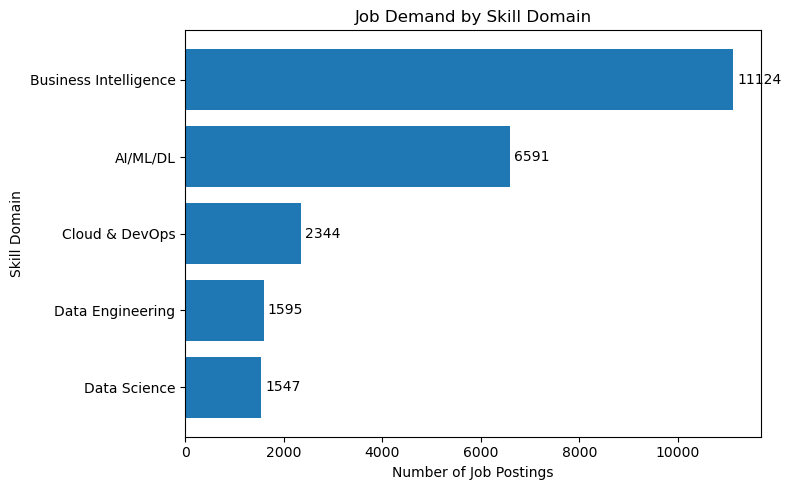

In [20]:
plt.figure(figsize=(8,5))

plt.barh(
    skill_demand["skill_domain"],
    skill_demand["total_jobs"]
)

plt.title("Job Demand by Skill Domain")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill Domain")

plt.gca().invert_yaxis()

for index, value in enumerate(skill_demand["total_jobs"]):
    plt.text(value + 80, index, str(value), va='center')

plt.tight_layout()
plt.show()

### Key Insight

Business Intelligence is the most in-demand skill domain with **11,124 job postings**, followed by **AI/ML/DL (6,591)**.

Although Business Intelligence dominates the job market in terms of demand, it does not offer the highest average salary. In contrast, Cloud & DevOps offers the highest average disclosed salary despite having significantly fewer job postings.

This suggests that market demand and salary potential are not always directly proportional, highlighting the importance of evaluating both job availability and compensation when making career decisions.

# Top Hiring Cities

### 1.3 Top Hiring Cities

This analysis identifies the cities with the highest number of technology job postings.

Understanding geographic hiring patterns helps identify major employment hubs and regions with strong demand for data and analytics professionals.

In [24]:
top_cities = pd.read_sql("""
SELECT
    l.primary_city,
    COUNT(*) AS total_jobs
FROM fact_jobs f
JOIN dim_location l
    ON f.location_key = l.location_key
GROUP BY l.primary_city
ORDER BY total_jobs DESC
LIMIT 10;
""", engine)

top_cities

,primary_city,total_jobs
0,Mumbai,3276
1,Bangalore,2830
2,Chennai,2666
3,Pune,2606
4,Noida,2585
5,Gurgaon,2210
6,Remote,2010
7,Kolkata,1735
8,Ahmedabad,1352
9,Delhi,920


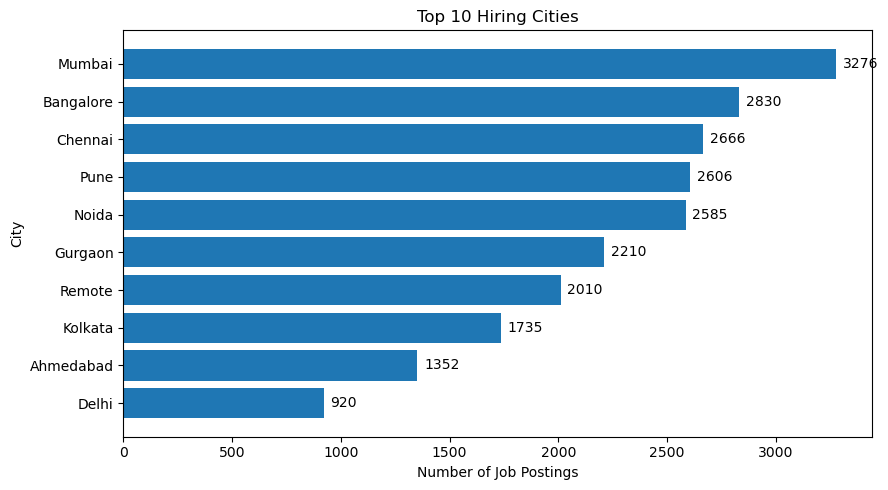

In [26]:
plt.figure(figsize=(9,5))

plt.barh(
    top_cities["primary_city"],
    top_cities["total_jobs"]
)

plt.title("Top 10 Hiring Cities")
plt.xlabel("Number of Job Postings")
plt.ylabel("City")

plt.gca().invert_yaxis()

for index, value in enumerate(top_cities["total_jobs"]):
    plt.text(value + 30, index, str(value), va='center')

plt.tight_layout()
plt.show()

### Business Interpretation

The analysis shows that **Mumbai** is the largest technology hiring hub with **3,276 job postings**, followed by **Bangalore (2,830)** and **Chennai (2,666)**.

Traditional IT hubs continue to dominate the Indian job market, while emerging cities such as **Noida** and **Gurgaon** also contribute significantly to technology hiring.

The presence of **Remote** as a separate category with **2,010 job postings** highlights the continued adoption of remote work opportunities across the technology sector.

### Key Insight

Mumbai, Bangalore, and Chennai collectively represent the strongest hiring markets in the dataset.

The significant number of remote opportunities demonstrates that organizations continue to offer location-independent roles alongside traditional office-based hiring.

# Top Hiring Companies

### 1.4 Top Hiring Companies

This analysis identifies the organizations with the highest number of job postings.

The objective is to understand which companies contribute most significantly to hiring activity within the dataset.

In [31]:
top_companies = pd.read_sql("""
SELECT
    c.company_name,
    COUNT(*) AS total_jobs
FROM fact_jobs f
JOIN dim_company c
    ON f.company_key = c.company_key
GROUP BY c.company_name
HAVING COUNT(*) >= 5
ORDER BY total_jobs DESC
LIMIT 10;
""", engine)

top_companies

,company_name,total_jobs
0,Tata Consultancy Services,654
1,Accenture,438
2,EY,340
3,Leading Client,244
4,Infosys,209
5,Capgemini,195
6,Photon,193
7,Logic Planet,185
8,Hexaware Technologies,147
9,Sparix Global,126


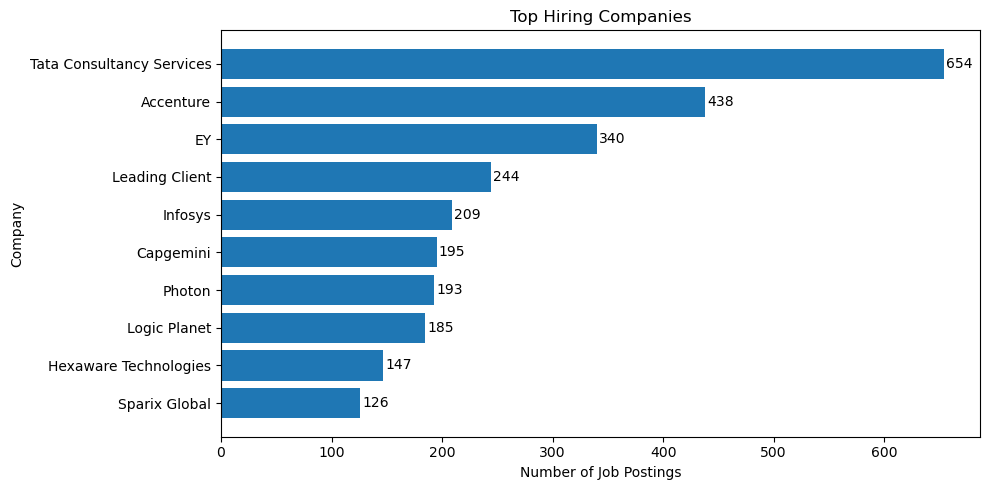

In [33]:
plt.figure(figsize=(10,5))

plt.barh(
    top_companies["company_name"],
    top_companies["total_jobs"]
)

plt.title("Top Hiring Companies")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")

plt.gca().invert_yaxis()

for index, value in enumerate(top_companies["total_jobs"]):
    plt.text(value + 2, index, str(value), va='center')

plt.tight_layout()
plt.show()

### Business Interpretation

Among the analyzed companies, **Tata Consultancy Services (TCS)** has the highest hiring activity with **654 job postings**, followed by **Accenture (438)** and **EY (340)**.

The ranking indicates that large consulting firms and IT service organizations remain major employers for technology and analytics professionals.

Several multinational consulting and technology companies consistently appear among the top recruiters, reflecting sustained demand for data-driven roles across enterprise organizations.

### Key Insight

Large IT service providers and consulting organizations dominate hiring activity within the dataset.

Tata Consultancy Services leads all companies in total job postings, while Accenture and EY also demonstrate strong recruitment activity, indicating that enterprise consulting firms continue to be key employers in the Indian technology job market.

# 2. Salary & Compensation Analysis

This section analyzes salary trends across different job roles, skill domains, work modes, cities, companies, and experience levels.

The objective is to understand the factors that influence compensation in the Indian technology job market.

### 2.1 Highest Paying Job Roles

This analysis compares the average disclosed salary across different job roles.

Only jobs with disclosed salary information are considered to ensure the analysis reflects actual compensation rather than missing salary values.

In [42]:
salary_by_role = pd.read_sql("""
SELECT
    r.role_category,
    COUNT(*) AS disclosed_jobs,
    ROUND(
        AVG(NULLIF(f.salary_midpoint_lpa,0)),
        2
    ) AS avg_salary
FROM fact_jobs f
JOIN dim_role r
    ON f.role_key = r.role_key
WHERE f.salary_midpoint_lpa > 0
GROUP BY r.role_category
HAVING COUNT(*) >= 5
ORDER BY avg_salary DESC;
""", engine)

salary_by_role

,role_category,disclosed_jobs,avg_salary
0,Data Scientist,756,18.61
1,Data Engineer,215,17.85
2,Machine Learning Engineer,473,16.29
3,Python Developer,222,15.72
4,Business Analyst,460,14.14
5,Data Analyst,640,10.62


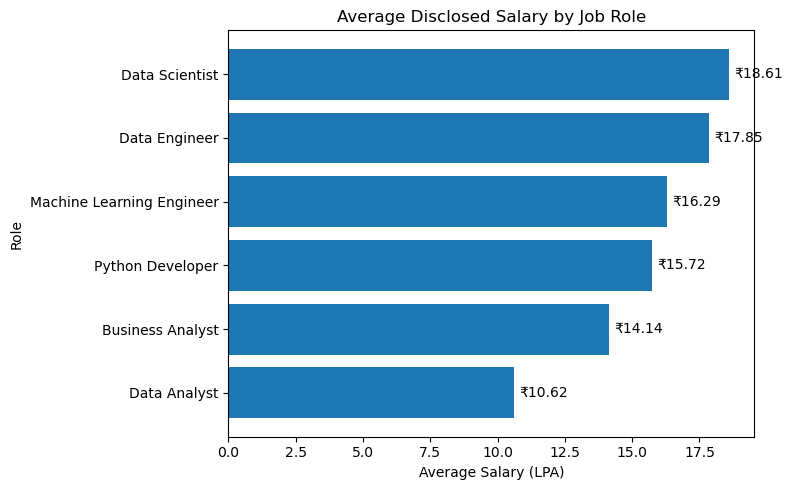

In [44]:
plt.figure(figsize=(8,5))

plt.barh(
    salary_by_role["role_category"],
    salary_by_role["avg_salary"]
)

plt.title("Average Disclosed Salary by Job Role")
plt.xlabel("Average Salary (LPA)")
plt.ylabel("Role")

plt.gca().invert_yaxis()

for index, value in enumerate(salary_by_role["avg_salary"]):
    plt.text(value + 0.2, index, f"₹{value:.2f}", va='center')

plt.tight_layout()
plt.show()

### Business Interpretation

Among the analyzed job roles, **Data Scientist** offers the highest average disclosed salary at **₹18.61 LPA**, followed closely by **Data Engineer (₹17.85 LPA)** and **Machine Learning Engineer (₹16.29 LPA)**.

Although **Data Analyst** has the second-highest demand in the dataset, it records the lowest average disclosed salary (**₹10.62 LPA**) among the analyzed roles.

This suggests that specialized technical positions generally command higher salaries than broader analytical roles.

### Key Insight

Specialized technical roles such as **Data Scientist**, **Data Engineer**, and **Machine Learning Engineer** receive the highest average salaries in the dataset.

While **Data Analyst** roles are highly demanded, their average disclosed salary is comparatively lower, indicating that strong market demand does not necessarily correspond to the highest compensation.

### 2.2 Highest Paying Skill Domains

This analysis compares the average disclosed salary across different technology skill domains.

It helps identify which technical specializations command the highest compensation in the market.

In [49]:
salary_by_skill = pd.read_sql("""
SELECT
    r.skill_domain,
    COUNT(*) AS disclosed_jobs,
    ROUND(
        AVG(NULLIF(f.salary_midpoint_lpa,0)),
        2
    ) AS avg_salary
FROM fact_jobs f
JOIN dim_role r
    ON f.role_key = r.role_key
WHERE f.salary_midpoint_lpa > 0
GROUP BY r.skill_domain
HAVING COUNT(*) >= 5
ORDER BY avg_salary DESC;
""", engine)

salary_by_skill

,skill_domain,disclosed_jobs,avg_salary
0,Cloud & DevOps,367,19.02
1,AI/ML/DL,784,18.26
2,Data Engineering,184,17.15
3,Data Science,204,13.76
4,Business Intelligence,1227,12.34


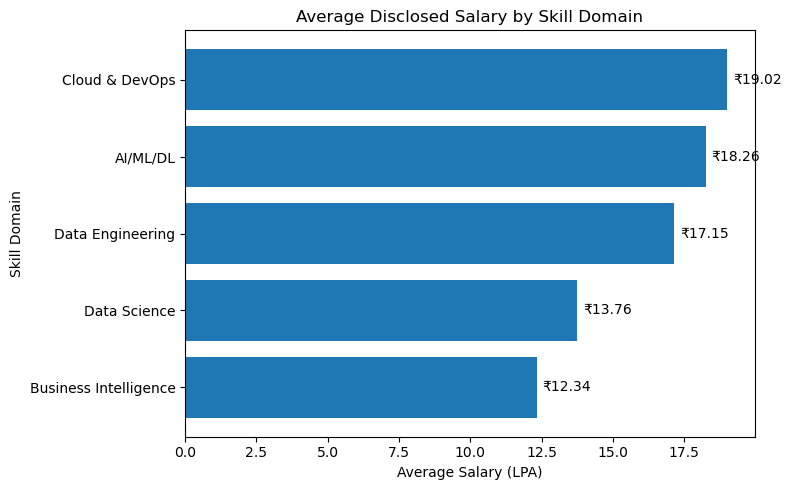

In [51]:
plt.figure(figsize=(8,5))

plt.barh(
    salary_by_skill["skill_domain"],
    salary_by_skill["avg_salary"]
)

plt.title("Average Disclosed Salary by Skill Domain")
plt.xlabel("Average Salary (LPA)")
plt.ylabel("Skill Domain")

plt.gca().invert_yaxis()

for index, value in enumerate(salary_by_skill["avg_salary"]):
    plt.text(value + 0.2, index, f"₹{value:.2f}", va='center')

plt.tight_layout()
plt.show()

### Business Interpretation

Among the five analyzed skill domains, **Cloud & DevOps** offers the highest average disclosed salary (**₹19.02 LPA**), followed closely by **AI/ML/DL (₹18.26 LPA)** and **Data Engineering (₹17.15 LPA)**.

Although **Business Intelligence** accounts for the largest share of job postings in the dataset, it has the lowest average disclosed salary (**₹12.34 LPA**).

This demonstrates a clear distinction between high-demand skill domains and premium-paying technical specializations.

### Key Insight

Cloud & DevOps and AI/ML/DL represent the highest-paying technical domains in the analyzed job market.

In contrast, Business Intelligence offers the greatest number of job opportunities but comparatively lower salary levels, highlighting the trade-off between employment demand and compensation.

### 2.3 Average Salary by Work Mode

This analysis compares the average disclosed salary across different work arrangements, including On-site, Hybrid, and Remote positions.

The objective is to determine whether work mode has an observable relationship with salary.

In [59]:
salary_by_workmode = pd.read_sql("""
SELECT
    r.work_mode,
    COUNT(*) AS disclosed_jobs,
    ROUND(
        AVG(NULLIF(f.salary_midpoint_lpa,0)),
        2
    ) AS avg_salary
FROM fact_jobs f
JOIN dim_role r
    ON f.role_key = r.role_key
WHERE f.salary_midpoint_lpa > 0
GROUP BY r.work_mode
ORDER BY avg_salary DESC;
""", engine)

salary_by_workmode

,work_mode,disclosed_jobs,avg_salary
0,Hybrid,721,21.01
1,Remote,166,14.49
2,On-site,1879,13.23


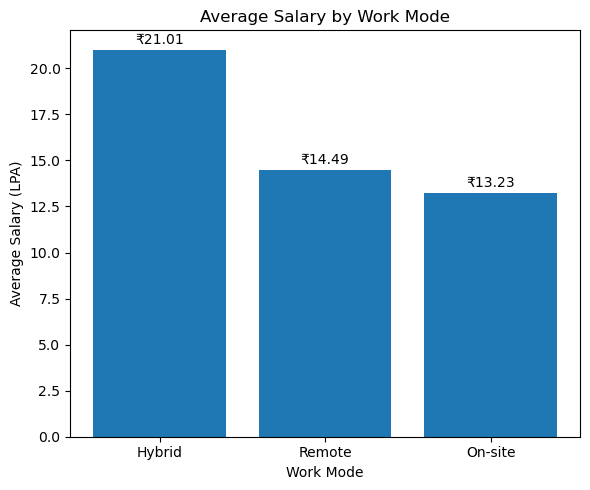

In [61]:
plt.figure(figsize=(6,5))

plt.bar(
    salary_by_workmode["work_mode"],
    salary_by_workmode["avg_salary"]
)

plt.title("Average Salary by Work Mode")
plt.xlabel("Work Mode")
plt.ylabel("Average Salary (LPA)")

for i, value in enumerate(salary_by_workmode["avg_salary"]):
    plt.text(i, value + 0.3, f"₹{value:.2f}", ha='center')

plt.tight_layout()
plt.show()

### Business Interpretation

The analysis indicates that **Hybrid** roles offer the highest average disclosed salary at **₹21.01 LPA**, significantly exceeding both **Remote (₹14.49 LPA)** and **On-site (₹13.23 LPA)** positions.

Although On-site roles account for the largest number of disclosed salary records (**1,879 jobs**), they have the lowest average salary among the three work modes.

This suggests that organizations may offer higher compensation for hybrid positions, potentially reflecting the demand for experienced professionals and flexible working arrangements.

### Key Insight

Hybrid work opportunities command the highest average salary in the dataset, averaging **₹21.01 LPA**, while On-site positions have the lowest average disclosed salary.

The findings indicate that work mode is associated with salary differences, with Hybrid roles providing the strongest compensation among the analyzed work arrangements.

### 2.4 Top Paying Cities

This analysis identifies the cities offering the highest average disclosed salaries.

To improve the reliability of the results, only cities with at least **5 disclosed salary records** are included in the analysis.

In [68]:
salary_city = pd.read_sql("""
SELECT
    l.location,
    COUNT(*) AS disclosed_jobs,
    ROUND(
        AVG(NULLIF(f.salary_midpoint_lpa,0)),
        2
    ) AS avg_salary
FROM fact_jobs f
JOIN dim_location l
    ON f.location_key = l.location_key
WHERE f.salary_midpoint_lpa > 0
GROUP BY l.location
HAVING COUNT(*) >= 5
ORDER BY avg_salary DESC
LIMIT 10;
""", engine)

salary_city

,location,disclosed_jobs,avg_salary
0,"Hybrid - Noida, Gurugram, Delhi / NCR",5,32.00
1,"Hybrid - Delhi / NCR, Pune, Bengaluru",5,28.15
2,"Noida, Pune, Bengaluru",7,28.04
3,"Hybrid - Pune, Gurugram, Bengaluru",24,27.91
4,"Hybrid - Pune, Bengaluru, Delhi / NCR",6,27.21
5,"Hybrid - Hyderabad, Gurugram, Bengaluru",9,25.94
6,"Hybrid - Delhi / NCR, Gurugram, Bengaluru",8,25.94
7,"Hybrid - Gurugram, Bengaluru, Delhi / NCR",8,25.94
8,"Chennai, Hyderabad",6,25.50
9,"Pune, Bengaluru",7,23.93


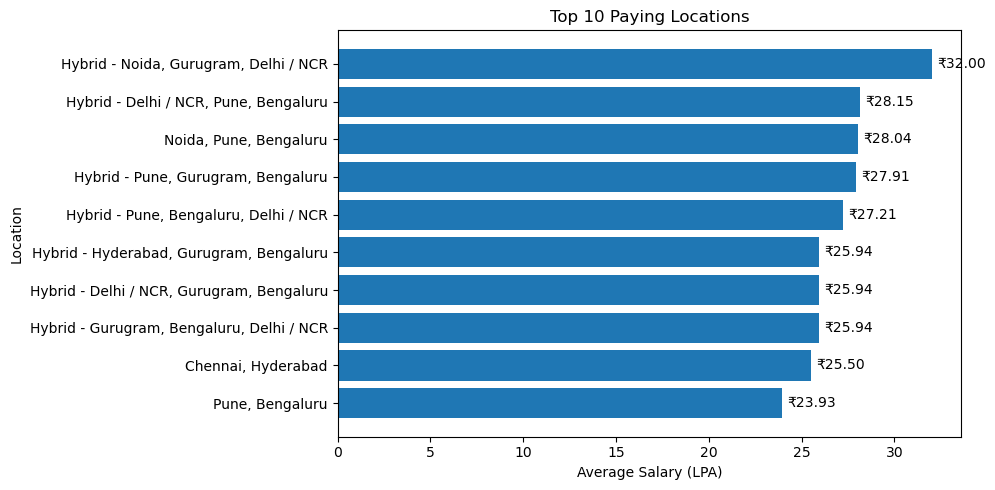

In [70]:
plt.figure(figsize=(10,5))

plt.barh(
    salary_city["location"],
    salary_city["avg_salary"]
)

plt.title("Top 10 Paying Locations")
plt.xlabel("Average Salary (LPA)")
plt.ylabel("Location")

plt.gca().invert_yaxis()

for i, value in enumerate(salary_city["avg_salary"]):
    plt.text(value + 0.3, i, f"₹{value:.2f}", va='center')

plt.tight_layout()
plt.show()

### Business Interpretation

The analysis identifies the job locations with the highest average disclosed salaries, considering only locations with at least five disclosed salary records.

Several of the highest-paying entries represent hybrid or multi-city hiring locations, indicating that organizations recruiting across multiple technology hubs tend to offer higher compensation packages.

This suggests that flexible hiring strategies and positions spanning major technology centers are often associated with premium salary offerings.

### Key Insight

The highest average salaries are concentrated in hybrid and multi-location job postings rather than a single geographic city.

Organizations hiring across multiple technology hubs appear to offer more competitive compensation, reflecting the demand for experienced professionals with greater geographic flexibility.

### 2.5 Top Paying Companies

This analysis identifies the companies offering the highest average disclosed salaries.

To improve the reliability of the results, only companies with at least **5 disclosed salary records** are included in the analysis.

In [75]:
salary_company = pd.read_sql("""
SELECT
    c.company_name,
    COUNT(*) AS disclosed_jobs,
    ROUND(
        AVG(NULLIF(f.salary_midpoint_lpa,0)),
        2
    ) AS avg_salary
FROM fact_jobs f
JOIN dim_company c
    ON f.company_key = c.company_key
WHERE f.salary_midpoint_lpa > 0
GROUP BY c.company_name
HAVING COUNT(*) >= 5
ORDER BY avg_salary DESC
LIMIT 10;
""", engine)

salary_company

,company_name,disclosed_jobs,avg_salary
0,Fortune 500 IT MNC,8,40.00
1,Optum,11,35.11
2,KPI Partners,14,31.95
3,EXL,11,28.86
4,Wize Careers Consultants,5,28.70
5,US MNC (analytics),61,28.67
6,eLabs Infotech,6,28.54
7,Calsoft,6,27.83
8,Kiash Solutions LLP,7,27.21
9,Leading IT Software Company,8,26.69


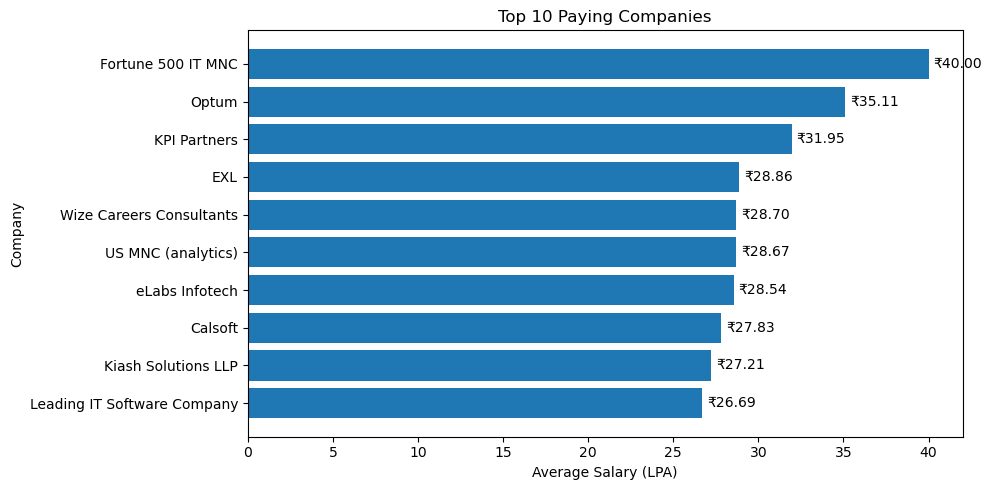

In [77]:
plt.figure(figsize=(10,5))

plt.barh(
    salary_company["company_name"],
    salary_company["avg_salary"]
)

plt.title("Top 10 Paying Companies")
plt.xlabel("Average Salary (LPA)")
plt.ylabel("Company")

plt.gca().invert_yaxis()

for i, value in enumerate(salary_company["avg_salary"]):
    plt.text(value + 0.3, i, f"₹{value:.2f}", va='center')

plt.tight_layout()
plt.show()

### Business Interpretation

The analysis identifies **Fortune 500 IT MNC** as the highest-paying company in the dataset, offering an average disclosed salary of **₹40.00 LPA**, followed by **Optum (₹35.11 LPA)** and **KPI Partners (₹31.95 LPA)**.

Several multinational organizations and analytics-focused companies appear among the highest-paying employers, indicating that specialized technology firms and global enterprises tend to offer more competitive compensation packages.

The inclusion of a minimum threshold of five disclosed salary records improves the reliability of the rankings by reducing the influence of isolated salary disclosures.

### Key Insight

Premium salaries are primarily offered by multinational technology companies and specialized analytics organizations.

Fortune 500 IT MNC leads the ranking with an average disclosed salary of ₹40.00 LPA, while Optum and KPI Partners also demonstrate strong compensation levels, highlighting the value placed on advanced technical expertise.

### 2.6 Salary Progression by Experience Level

This analysis examines how average disclosed salary changes across different experience levels, from Freshers to Lead/Architect positions.

Understanding salary progression helps illustrate the financial growth associated with career advancement in the technology industry.

In [82]:
salary_experience = pd.read_sql("""
SELECT
    r.experience_tier,
    COUNT(*) AS disclosed_jobs,
    ROUND(
        AVG(NULLIF(f.salary_midpoint_lpa,0)),
        2
    ) AS avg_salary
FROM fact_jobs f
JOIN dim_role r
    ON f.role_key = r.role_key
WHERE f.salary_midpoint_lpa > 0
GROUP BY r.experience_tier
ORDER BY
CASE r.experience_tier
    WHEN 'Fresher' THEN 1
    WHEN 'Junior (0-2 Yrs)' THEN 2
    WHEN 'Mid (3-5 Yrs)' THEN 3
    WHEN 'Senior (6-8 Yrs)' THEN 4
    WHEN 'Lead/Architect (9+ Yrs)' THEN 5
END;
""", engine)

salary_experience

,experience_tier,disclosed_jobs,avg_salary
0,Fresher,237,9.62
1,Junior (0-2 Yrs),360,6.97
2,Mid (3-5 Yrs),1293,14.45
3,Senior (6-8 Yrs),730,20.28
4,Lead/Architect (9+ Yrs),146,28.29


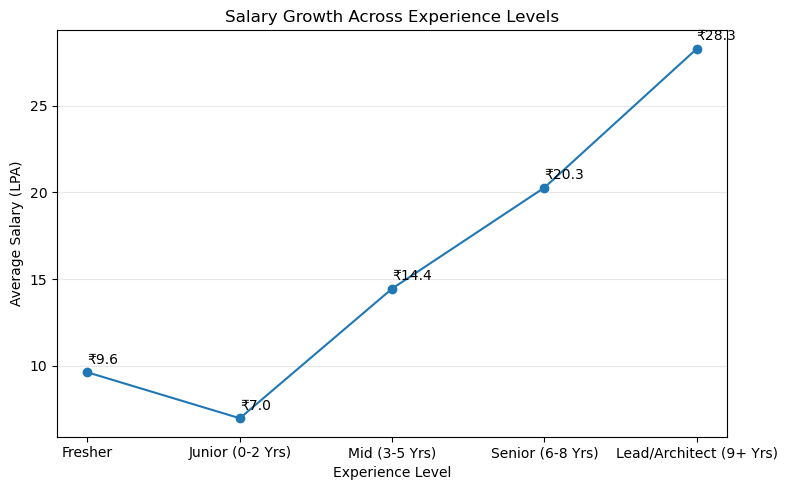

In [84]:
plt.figure(figsize=(8,5))

plt.plot(
    salary_experience["experience_tier"],
    salary_experience["avg_salary"],
    marker='o'
)

plt.title("Salary Growth Across Experience Levels")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (LPA)")

for i, value in enumerate(salary_experience["avg_salary"]):
    plt.text(i, value + 0.5, f"₹{value:.1f}")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Business Interpretation

The analysis shows a clear increase in average disclosed salary as professional experience grows.

Lead/Architect professionals receive the highest average salary at **₹28.29 LPA**, followed by Senior professionals at **₹20.28 LPA** and Mid-level professionals at **₹14.45 LPA**.

An interesting observation is that Freshers report a slightly higher average salary (**₹9.62 LPA**) than Junior professionals (**₹6.97 LPA**). This difference is likely influenced by the smaller number of disclosed fresher salaries and the presence of a few premium graduate hiring opportunities.

Overall, the results demonstrate a strong positive relationship between experience and compensation.

### Key Insight

Salary growth closely follows career progression, with average compensation increasing substantially from Mid-level roles onwards.

Lead/Architect professionals earn nearly three times the average salary of Junior professionals, highlighting the significant financial benefits associated with gaining experience and advancing into senior technical positions.

# 3. Hiring Trends & Market Insights

This section explores the current hiring landscape by analyzing job demand across cities, companies, work modes, role categories, and skill domains.

The objective is to identify where hiring activity is concentrated and understand the overall demand trends within the technology job market.

### 3.1 Top Hiring Cities

This analysis identifies the cities with the highest number of job postings in the dataset.

Understanding geographic hiring demand helps identify the major employment hubs for technology professionals.

In [90]:
top_hiring_cities = pd.read_sql("""
SELECT
    l.primary_city,
    COUNT(*) AS total_jobs
FROM fact_jobs f
JOIN dim_location l
ON f.location_key = l.location_key
GROUP BY l.primary_city
ORDER BY total_jobs DESC
LIMIT 10;
""", engine)

top_hiring_cities

,primary_city,total_jobs
0,Mumbai,3276
1,Bangalore,2830
2,Chennai,2666
3,Pune,2606
4,Noida,2585
5,Gurgaon,2210
6,Remote,2010
7,Kolkata,1735
8,Ahmedabad,1352
9,Delhi,920


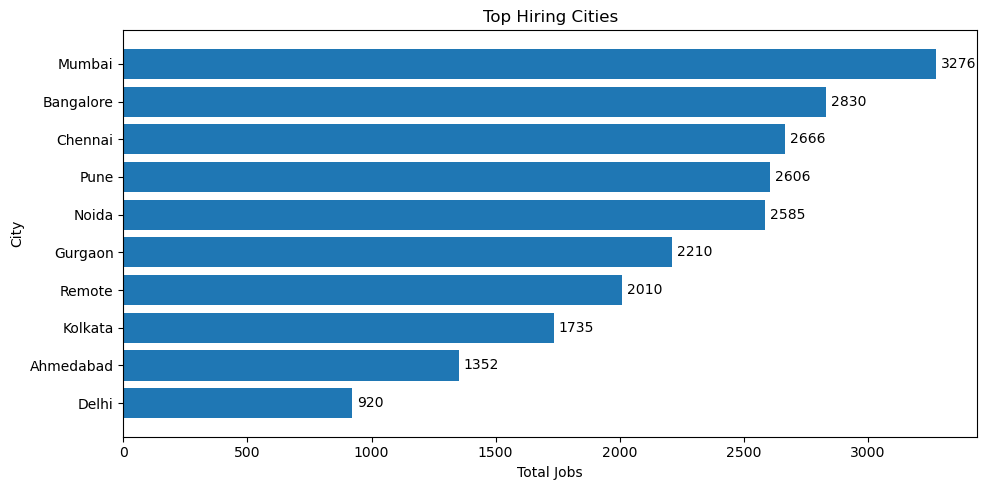

In [92]:
plt.figure(figsize=(10,5))

plt.barh(
    top_hiring_cities["primary_city"],
    top_hiring_cities["total_jobs"]
)

plt.gca().invert_yaxis()

plt.title("Top Hiring Cities")
plt.xlabel("Total Jobs")
plt.ylabel("City")

for i,v in enumerate(top_hiring_cities["total_jobs"]):
    plt.text(v+20,i,str(v),va='center')

plt.tight_layout()
plt.show()

### Business Interpretation

Mumbai emerges as the largest hiring hub with **3,276 job postings**, followed by **Bangalore (2,830)** and **Chennai (2,666)**.

The results indicate that hiring activity is concentrated in major metropolitan technology centers, reflecting the presence of large IT companies, consulting firms, and technology startups.

The appearance of **Remote** opportunities among the top hiring locations also highlights the growing adoption of location-independent recruitment.

### Key Insight

Technology hiring is heavily concentrated in India's major metropolitan cities, with Mumbai, Bangalore, and Chennai leading the job market.

The significant number of remote opportunities further suggests that flexible work arrangements have become an important component of technology recruitment.

### 3.2 Top Hiring Companies

This analysis identifies the companies with the highest number of job postings in the dataset.

Understanding which organizations recruit the most helps identify major employers and provides insight into the overall hiring landscape of the technology industry.

In [98]:
top_hiring_companies = pd.read_sql("""
SELECT
    c.company_name,
    COUNT(*) AS total_jobs
FROM fact_jobs f
JOIN dim_company c
    ON f.company_key = c.company_key
GROUP BY c.company_name
HAVING COUNT(*) >= 5
ORDER BY total_jobs DESC
LIMIT 10;
""", engine)

top_hiring_companies

,company_name,total_jobs
0,Tata Consultancy Services,654
1,Accenture,438
2,EY,340
3,Leading Client,244
4,Infosys,209
5,Capgemini,195
6,Photon,193
7,Logic Planet,185
8,Hexaware Technologies,147
9,Sparix Global,126


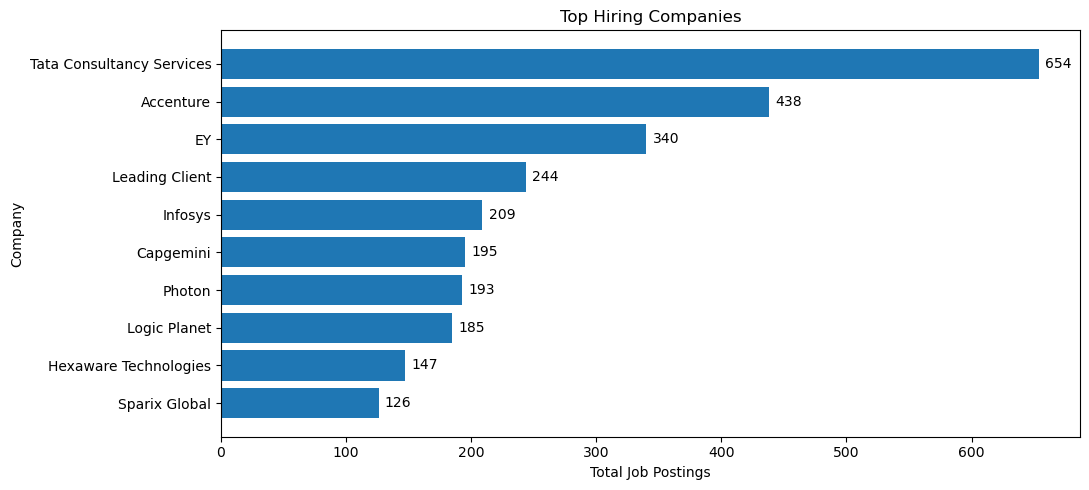

In [100]:
plt.figure(figsize=(11,5))

plt.barh(
    top_hiring_companies["company_name"],
    top_hiring_companies["total_jobs"]
)

plt.gca().invert_yaxis()

plt.title("Top Hiring Companies")
plt.xlabel("Total Job Postings")
plt.ylabel("Company")

for i, value in enumerate(top_hiring_companies["total_jobs"]):
    plt.text(value + 5, i, str(value), va='center')

plt.tight_layout()
plt.show()

### Business Interpretation

The analysis identifies **Tata Consultancy Services (TCS)** as the largest recruiter in the dataset with **654 job postings**, followed by **Accenture (438)** and **EY (340)**.

The results indicate that large IT service providers and consulting firms continue to dominate technology hiring, reflecting their broad service portfolios and continuous demand for skilled professionals.

Applying a minimum threshold of five job postings ensures that the ranking highlights organizations with consistent hiring activity.

### Key Insight

Large multinational IT and consulting companies account for a significant share of technology hiring.

TCS, Accenture, and EY collectively represent substantial recruitment demand, demonstrating that established organizations remain the primary employers for technology professionals.

### 3.3 Job Distribution by Work Mode

This analysis examines the distribution of job postings across different work modes.

Understanding hiring preferences for On-site, Hybrid, and Remote roles provides insight into current workplace trends and organizational hiring strategies.

In [105]:
work_mode_distribution = pd.read_sql("""
SELECT
    r.work_mode,
    COUNT(*) AS total_jobs,
    ROUND(
        COUNT(*) * 100.0 / (
            SELECT COUNT(*)
            FROM fact_jobs
        ),
        2
    ) AS percentage
FROM fact_jobs f
JOIN dim_role r
    ON f.role_key = r.role_key
GROUP BY r.work_mode
ORDER BY total_jobs DESC;
""", engine)

work_mode_distribution

,work_mode,total_jobs,percentage
0,On-site,18701,80.60
1,Hybrid,2347,10.12
2,Remote,2153,9.28


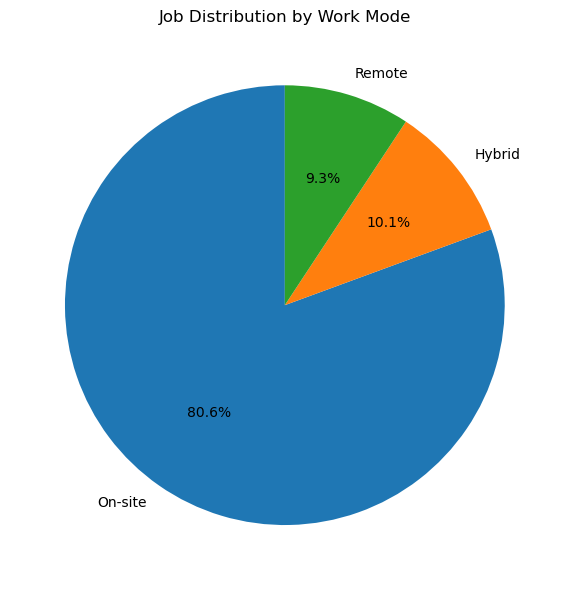

In [111]:
plt.figure(figsize=(6,6))

plt.pie(
    work_mode_distribution["total_jobs"],
    labels=work_mode_distribution["work_mode"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Job Distribution by Work Mode")

plt.tight_layout()
plt.show()

### Business Interpretation

The analysis reveals that **On-site** roles dominate the technology job market, accounting for **80.60%** of all job postings.

**Hybrid** positions represent **10.12%** of total opportunities, while **Remote** jobs account for **9.28%**.

These findings indicate that although flexible work arrangements have become more common, the majority of employers continue to prioritize office-based hiring.

### Key Insight

More than **80%** of technology job postings require employees to work on-site, making it the dominant work arrangement in the current job market.

Hybrid and Remote opportunities together account for nearly **20%** of job postings, demonstrating a gradual shift toward flexible work models while maintaining a strong preference for in-office collaboration.

### Key Insight

More than **80%** of technology job postings require employees to work on-site, making it the dominant work arrangement in the current job market.

Hybrid and Remote opportunities together account for nearly **20%** of job postings, demonstrating a gradual shift toward flexible work models while maintaining a strong preference for in-office collaboration.

In [116]:
role_demand = pd.read_sql("""
SELECT
    r.role_category,
    COUNT(*) AS total_jobs
FROM fact_jobs f
JOIN dim_role r
ON f.role_key = r.role_key
GROUP BY r.role_category
ORDER BY total_jobs DESC;
""", engine)

role_demand

,role_category,total_jobs
0,Data Scientist,6455
1,Data Analyst,4729
2,Business Analyst,4505
3,Machine Learning Engineer,4004
4,Data Engineer,1922
5,Python Developer,1586


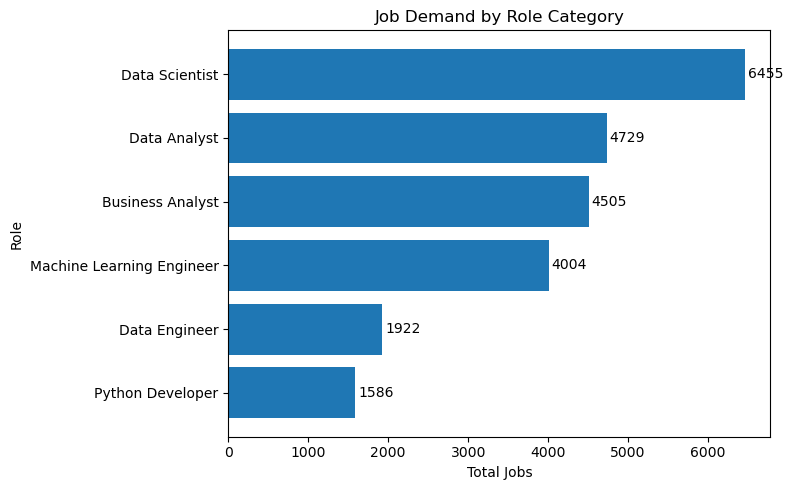

In [118]:
plt.figure(figsize=(8,5))

plt.barh(
    role_demand["role_category"],
    role_demand["total_jobs"]
)

plt.gca().invert_yaxis()

plt.title("Job Demand by Role Category")
plt.xlabel("Total Jobs")
plt.ylabel("Role")

for i, value in enumerate(role_demand["total_jobs"]):
    plt.text(value + 40, i, str(value), va='center')

plt.tight_layout()
plt.show()

### Business Interpretation

The analysis identifies **Data Scientist** as the most in-demand role with **6,455 job postings**, followed by **Data Analyst (4,729)** and **Business Analyst (4,505)**.

Together, these three roles account for a significant proportion of technology hiring, highlighting the increasing importance of data-driven decision-making across industries.

The strong demand for Machine Learning Engineers and Data Engineers further demonstrates the growing adoption of advanced analytics, artificial intelligence, and data infrastructure technologies.

### Key Insight

Data Scientist, Data Analyst, and Business Analyst are the most sought-after roles in the technology job market.

The results indicate that organizations are investing heavily in both data analysis and advanced AI capabilities, creating strong career opportunities across multiple data-focused professions.

### 3.5 Most In-Demand Skill Domains

This analysis examines hiring demand across different technology skill domains.

The objective is to identify which technical specializations receive the greatest number of job opportunities.

In [123]:
skill_demand = pd.read_sql("""
SELECT
    r.skill_domain,
    COUNT(*) AS total_jobs
FROM fact_jobs f
JOIN dim_role r
ON f.role_key = r.role_key
GROUP BY r.skill_domain
ORDER BY total_jobs DESC;
""", engine)

skill_demand

,skill_domain,total_jobs
0,Business Intelligence,11124
1,AI/ML/DL,6591
2,Cloud & DevOps,2344
3,Data Engineering,1595
4,Data Science,1547


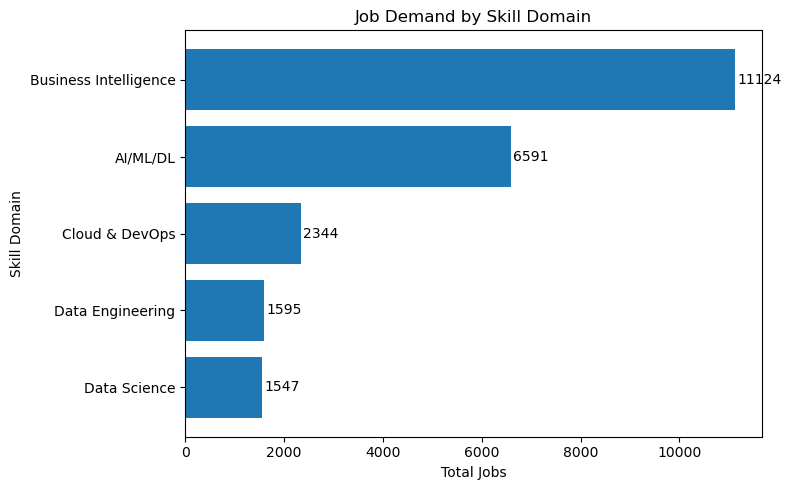

In [125]:
plt.figure(figsize=(8,5))

plt.barh(
    skill_demand["skill_domain"],
    skill_demand["total_jobs"]
)

plt.gca().invert_yaxis()

plt.title("Job Demand by Skill Domain")
plt.xlabel("Total Jobs")
plt.ylabel("Skill Domain")

for i, value in enumerate(skill_demand["total_jobs"]):
    plt.text(value + 50, i, str(value), va='center')

plt.tight_layout()
plt.show()

### Business Interpretation

The analysis shows that **Business Intelligence** is the most in-demand skill domain with **11,124 job postings**, followed by **AI/ML/DL (6,591)** and **Cloud & DevOps (2,344)**.

The high demand for Business Intelligence highlights the widespread need for professionals capable of transforming business data into actionable insights.

Meanwhile, the strong presence of AI/ML/DL opportunities reflects the rapid adoption of artificial intelligence and machine learning technologies across industries.

### Key Insight

Business Intelligence represents the largest hiring segment in the technology job market, while AI/ML/DL continues to experience substantial demand.

The results indicate that organizations are investing in both traditional business analytics and emerging AI-driven technologies, creating diverse career opportunities across multiple technical domains.

# 4. Experience & Skills Analysis

This section explores the relationship between professional experience, technical skills, hiring demand, and compensation.

The objective is to understand how experience and skill specialization influence career opportunities and salary growth in the technology job market.

### 4.1 Hiring Demand by Experience Level

This analysis identifies the number of job postings available for each experience level.

Understanding experience-wise hiring demand helps job seekers identify where the largest employment opportunities exist.

In [131]:
experience_demand = pd.read_sql("""
SELECT
    r.experience_tier,
    COUNT(*) AS total_jobs
FROM fact_jobs f
JOIN dim_role r
ON f.role_key = r.role_key
GROUP BY r.experience_tier
ORDER BY
CASE r.experience_tier
    WHEN 'Fresher' THEN 1
    WHEN 'Junior (0-2 Yrs)' THEN 2
    WHEN 'Mid (3-5 Yrs)' THEN 3
    WHEN 'Senior (6-8 Yrs)' THEN 4
    WHEN 'Lead/Architect (9+ Yrs)' THEN 5
END;
""", engine)

experience_demand

,experience_tier,total_jobs
0,Fresher,2219
1,Junior (0-2 Yrs),4915
2,Mid (3-5 Yrs),10112
3,Senior (6-8 Yrs),4810
4,Lead/Architect (9+ Yrs),1145


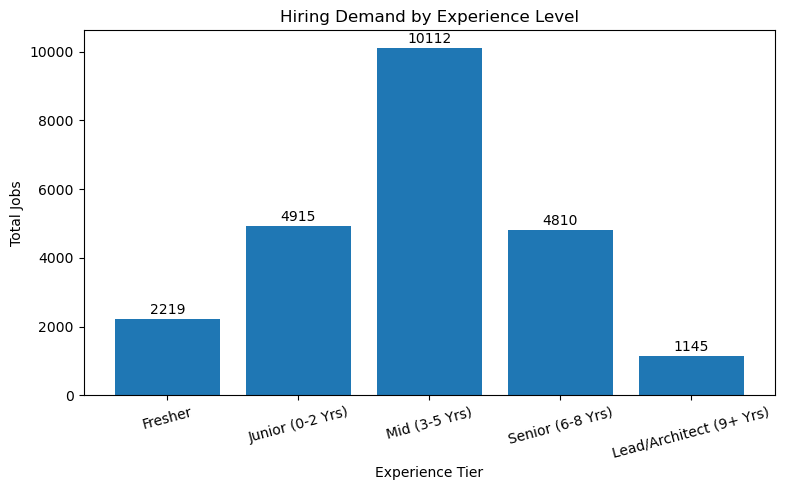

In [133]:
plt.figure(figsize=(8,5))

plt.bar(
    experience_demand["experience_tier"],
    experience_demand["total_jobs"]
)

plt.title("Hiring Demand by Experience Level")
plt.xlabel("Experience Tier")
plt.ylabel("Total Jobs")

for i, value in enumerate(experience_demand["total_jobs"]):
    plt.text(i, value + 150, str(value), ha='center')

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Business Interpretation

The analysis shows that **Mid-level professionals (3–5 years)** have the highest hiring demand, with **10,112 job postings**, accounting for the largest share of employment opportunities.

This is followed by **Junior professionals (0–2 years)** with **4,915 job postings** and **Senior professionals (6–8 years)** with **4,810 job postings**.

Hiring demand decreases significantly for **Lead/Architect** roles, reflecting the specialized nature of leadership positions and the relatively limited number of senior openings compared to mid-level technical roles.

### Key Insight

The technology job market is primarily driven by demand for **Mid-level professionals**, indicating that organizations actively seek candidates with practical industry experience and the ability to contribute with minimal training.

While opportunities exist across all experience levels, professionals with **3–5 years of experience** have the widest range of employment opportunities.

### 4.2 Average Skills Required by Skill Domain

This analysis examines the average number of skills required across different technology domains.

Understanding the skill requirements of each domain helps identify which career paths demand broader technical expertise.

In [142]:
skills_by_domain = pd.read_sql("""
SELECT
    r.skill_domain,
    COUNT(*) AS total_jobs,
    ROUND(AVG(f.skills_count),2) AS avg_skills_required
FROM fact_jobs f
JOIN dim_role r
ON f.role_key = r.role_key
GROUP BY r.skill_domain
ORDER BY avg_skills_required DESC;
""", engine)

skills_by_domain

,skill_domain,total_jobs,avg_skills_required
0,Cloud & DevOps,2344,7.74
1,AI/ML/DL,6591,7.71
2,Business Intelligence,11124,7.61
3,Data Engineering,1595,7.41
4,Data Science,1547,7.12


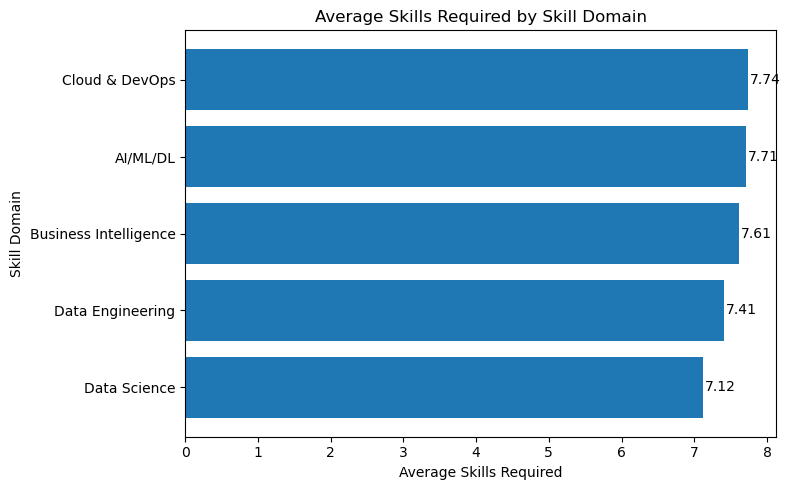

In [144]:
plt.figure(figsize=(8,5))

plt.barh(
    skills_by_domain["skill_domain"],
    skills_by_domain["avg_skills_required"]
)

plt.gca().invert_yaxis()

plt.title("Average Skills Required by Skill Domain")
plt.xlabel("Average Skills Required")
plt.ylabel("Skill Domain")

for i, value in enumerate(skills_by_domain["avg_skills_required"]):
    plt.text(value + 0.03, i, f"{value:.2f}", va='center')

plt.tight_layout()
plt.show()

### Business Interpretation

The analysis reveals that **Cloud & DevOps** roles require the broadest technical expertise, with an average of **7.74 skills** per job posting. **AI/ML/DL** follows closely with **7.71 skills**, while **Business Intelligence** positions require an average of **7.61 skills**.

Although the differences between domains are relatively small, the results indicate that employers generally expect candidates across all technology domains to possess a diverse set of technical competencies.

This highlights the increasing importance of multi-skilled professionals in today's technology job market.

### Key Insight

Cloud & DevOps and AI/ML/DL roles demand the highest average number of technical skills, reflecting the complexity of these domains and the expectation that professionals possess expertise across multiple technologies.

Overall, technology employers consistently seek candidates with broad and versatile skill sets regardless of specialization.

### 4.3 Role-wise Experience Distribution

This analysis examines how hiring demand for different job roles is distributed across various experience levels.

The objective is to understand which roles are more suitable for freshers, mid-level professionals, and experienced candidates.

In [149]:
role_experience = pd.read_sql("""
SELECT
    r.role_category,
    SUM(CASE WHEN r.experience_tier = 'Fresher' THEN 1 ELSE 0 END) AS fresher_jobs,
    SUM(CASE WHEN r.experience_tier = 'Junior (0-2 Yrs)' THEN 1 ELSE 0 END) AS junior_jobs,
    SUM(CASE WHEN r.experience_tier = 'Mid (3-5 Yrs)' THEN 1 ELSE 0 END) AS mid_jobs,
    SUM(CASE WHEN r.experience_tier = 'Senior (6-8 Yrs)' THEN 1 ELSE 0 END) AS senior_jobs,
    SUM(CASE WHEN r.experience_tier = 'Lead/Architect (9+ Yrs)' THEN 1 ELSE 0 END) AS lead_jobs,
    COUNT(*) AS total_jobs
FROM fact_jobs f
JOIN dim_role r
ON f.role_key = r.role_key
GROUP BY r.role_category
ORDER BY total_jobs DESC;
""", engine)

role_experience

,role_category,fresher_jobs,junior_jobs,mid_jobs,senior_jobs,lead_jobs,total_jobs
0,Data Scientist,495.0,1005.0,3074.0,1547.0,334.0,6455
1,Data Analyst,637.0,1432.0,1915.0,609.0,136.0,4729
2,Business Analyst,397.0,1070.0,1830.0,990.0,218.0,4505
3,Machine Learning Engineer,466.0,840.0,1578.0,817.0,303.0,4004
4,Data Engineer,92.0,270.0,930.0,508.0,122.0,1922
5,Python Developer,132.0,298.0,785.0,339.0,32.0,1586


### Business Interpretation

The analysis reveals distinct hiring patterns across different job roles and experience levels.

Data Scientist roles have the highest overall demand with **6,455 job postings**, with the majority targeting **Mid-level professionals (3,074 jobs)**. Similarly, Data Analyst and Business Analyst positions also show their strongest demand at the Mid-level experience tier.

Across all role categories, hiring is concentrated on professionals with **3–8 years of experience**, while Fresher and Lead/Architect positions represent a smaller share of total openings. This suggests that employers primarily seek candidates who possess practical industry experience and can contribute effectively with limited onboarding.

### Key Insight

Mid-level professionals form the backbone of technology hiring across all major role categories.

Among all roles, **Data Scientist** positions exhibit the highest demand, followed by **Data Analyst** and **Business Analyst**, indicating that organizations continue to invest heavily in data-driven decision-making and advanced analytics capabilities.

# 5. Business Recommendations & Conclusion

Based on the analyses performed throughout this project, several key insights and recommendations can be drawn regarding hiring trends, salary patterns, and skill requirements within the technology job market.

### Business Recommendations

1. **Focus hiring efforts on high-demand roles.**
   - Data Scientist, Data Analyst, and Business Analyst roles represent the largest share of job opportunities and should remain key hiring priorities.

2. **Invest in Business Intelligence and AI capabilities.**
   - Business Intelligence has the highest hiring demand, while AI/ML/DL continues to experience significant market growth.

3. **Develop multi-skilled professionals.**
   - Employers consistently expect candidates to possess a broad range of technical skills, particularly in Cloud & DevOps and AI/ML domains.

4. **Prioritize experienced talent for critical positions.**
   - Mid-level professionals account for the largest proportion of job postings, indicating strong demand for candidates with practical industry experience.

5. **Maintain competitive compensation for specialized roles.**
   - Organizations aiming to attract top talent in Cloud & DevOps, AI/ML, and senior technical positions should offer competitive salary packages aligned with market trends.

### Project Conclusion

This project successfully transformed raw technology job posting data into a structured analytical solution using a modern data analytics workflow.

The data was cleaned, engineered, and organized into a star schema before being analyzed using SQL and visualized through Power BI dashboards. Python and Matplotlib were further used to validate findings and generate analytical visualizations.

The analyses revealed strong demand for Data Scientist, Data Analyst, and Business Analyst roles, with Business Intelligence emerging as the most sought-after skill domain. Salary analysis showed that compensation increases significantly with professional experience, particularly for senior and leadership positions. Additionally, Cloud & DevOps and AI/ML professionals command some of the highest average salaries while also requiring broader technical expertise.

Overall, the project demonstrates proficiency in data cleaning, data warehousing, SQL querying, exploratory data analysis, business intelligence, data visualization, and the communication of actionable business insights, providing a comprehensive view of the current technology job market.